************************************************** Diabetes Prediction using Machine Learning**********************************************************

**Import Required Libraries**

These Python libraries help with:
- Data loading (Pandas)
- Numerical operations (NumPy)
- Visualization (Matplotlib & Seaborn)
- Machine Learning (Scikit-Learn)

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("All libraries imported successfully! ")


All libraries imported successfully! 


**Load Dataset**

Outcome = 1 → Diabetes Present  
Outcome = 0 → No Diabetes

In [ ]:
df = pd.read_csv('diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Data Exploration (EDA)**

Check structure, data types & statistics.

In [ ]:
print("Shape of Dataset:", df.shape)
df.info()
df.describe()


Shape of Dataset: (768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


 **Visualizing Data Distribution**

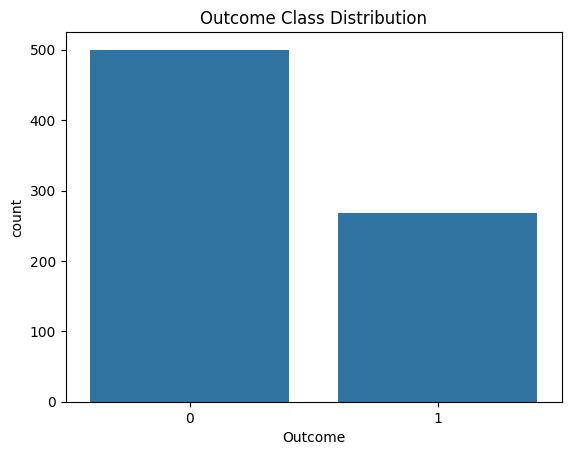

In [ ]:
sns.countplot(x='Outcome', data=df)
plt.title("Outcome Class Distribution")
plt.show()


**Correlation Heatmap**

Shows relation of each feature with diabetes

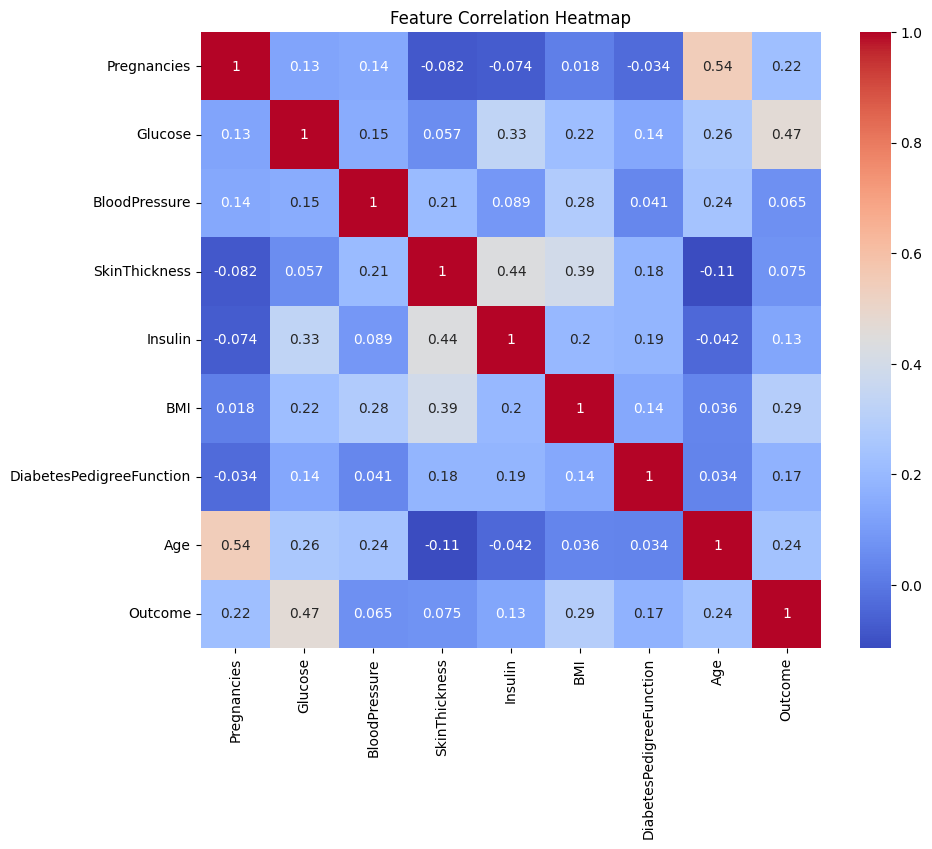

In [ ]:

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


**Data Cleaning**

Replace zero values in important features with median.

In [ ]:
invalid_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in invalid_cols:
    df[col] = df[col].replace(0, np.nan)
    df[col].fillna(df[col].median(), inplace=True)

print("Data Cleaning Done!")


Data Cleaning Done!


C:\Users\HP\AppData\Local\Temp\ipykernel_23940\991397554.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_23940\991397554.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when

**Train-Test Split**

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train/Test Split Done!")


Train/Test Split Done!


**Feature Scaling**

Important for KNN & Logistic Regression.

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Done!")


Feature Scaling Done!


**Train Multiple ML Models**

compare Logistic Regression, KNN, Decision Tree & Random Forest

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc

    print(f"\nModel: {name}")
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_test, pred))



Model: Logistic Regression
Accuracy: 0.7078
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


Model: KNN
Accuracy: 0.7532
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154


Model: Decision Tree
Accuracy: 0.6883
              precision    recall  f1-score   support

           0       0.75      0.78      0.76       100
           1       0.56      0.52      0.54        54

    accuracy                           0.69       154
   macro avg   

**Compare Model Accuracy**

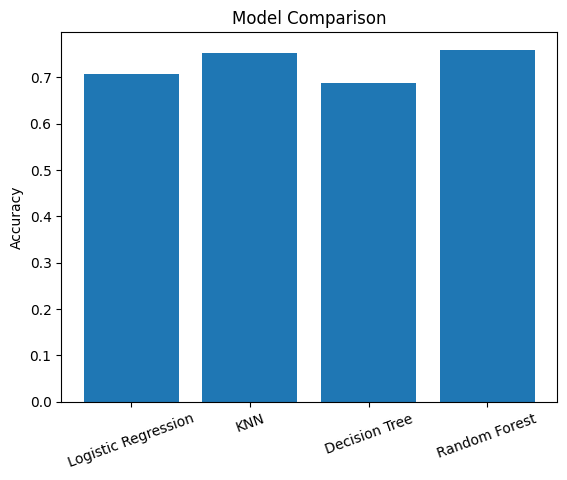

In [ ]:
plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()


**Confusion Matrix for Best Model**


Best Model: Random Forest


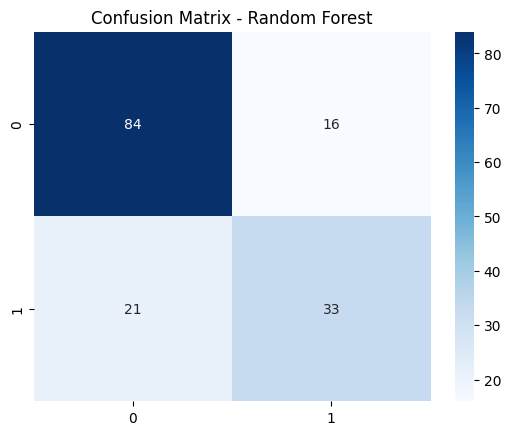

In [ ]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


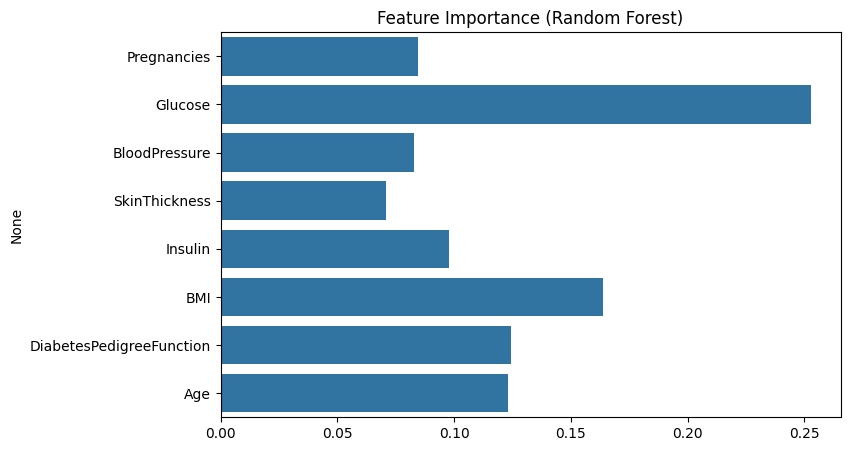

In [ ]:
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance (Random Forest)")
plt.show()


In [ ]:
import pickle
pickle.dump(best_model, open("diabetes_model.pkl", "wb"))
print("Model saved successfully!")


Model saved successfully!


 Diabetes Detected = 1
 No Diabetes Detected = 0

**Predict for New Patient Data**

In [ ]:
new_data = np.array([[11,120,80,37,150,42.3,0.785,48,1]])
new_data = scaler.transform(new_data)  

prediction = best_model.predict(new_data)

if prediction[0] == 1:
    print("🟥 Diabetes Detected!")
else:
    print("🟩 No Diabetes Detected!")


🟩 No Diabetes Detected!


d:\diabetis -ML model\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
